In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/products.csv", sep="\t")

In [3]:
df.columns

Index(['product_id', 'name', 'category', 'brand', 'price', 'stock', 'rating'], dtype='object')

In [4]:
df.head()

,product_id,name,category,brand,price,stock,rating
0,1,MacBook Pro M4 14,Laptop,Apple,10677.59,10.0,4.7
1,2,RTX 5070 Ti 16GB,GPU,NVIDIA,771.27,13.0,4.9
2,3,Core Ultra 5 245K,CPU,Intel,323.46,12.0,4.3
3,4,16GB DDR5-5600,RAM,Kingston,50.02,47.0,4.2
4,5,27in 4K OLED 240Hz,Monitor,ASUS,891.3,5.0,4.7


In [5]:
df.shape

(200, 7)

In [6]:
df.dtypes

product_id      int64
name           object
category       object
brand          object
price          object
stock         float64
rating        float64
dtype: object

In [7]:
df.isnull().sum()

product_id    0
name          0
category      0
brand         3
price         2
stock         3
rating        2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(4)

In [9]:
df["price"].describe()

count        198
unique       191
top       166.92
freq           2
Name: price, dtype: object

In [10]:
df["category"].value_counts()

category
SSD            36
CPU            30
GPU            27
RAM            24
Case           16
Mouse          15
Monitor        14
Motherboard    12
PSU            11
Headset         8
Laptop          7
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

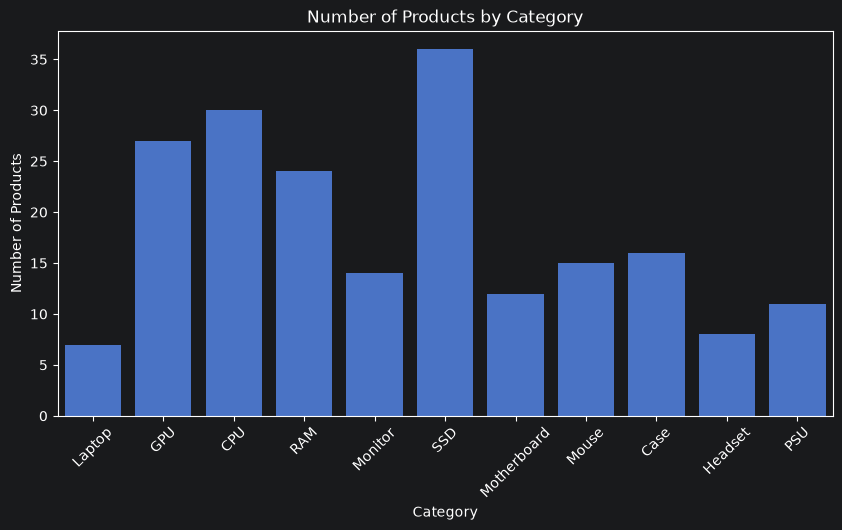

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="category")
plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

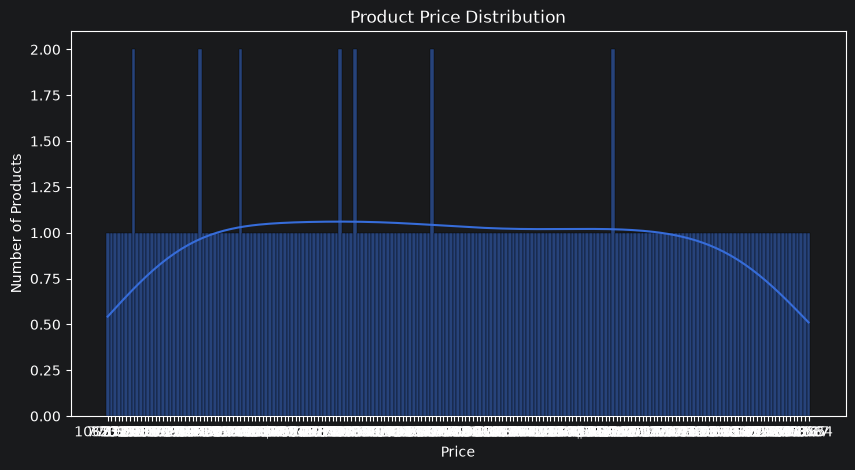

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="price", bins=20, kde=True)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

In [14]:
# category_price = df.groupby("category")["price"].mean()
# print(category_price)
print(df["price"].dtype)
print(df["price"].head(20))
df["price"] = (df["price"].astype(str).str.replace("$","", regex=False))
df["price"] = pd.to_numeric(df["price"], errors="coerce")
print(df["price"].dtype)
category_price = df.groupby("category")["price"].mean()
print(category_price)

object
0     10677.59
1       771.27
2       323.46
3        50.02
4        891.3
5       371.17
6       162.96
7       315.38
8        93.31
9       180.39
10      201.85
11       51.63
12     1971.22
13         NaN
14      354.57
15      597.27
16      154.61
17      386.98
18      161.14
19       77.23
Name: price, dtype: object
float64
category
CPU             369.207000
Case            114.590625
GPU            1115.991538
Headset         278.851250
Laptop         2958.718571
Monitor         675.204286
Motherboard     272.520000
Mouse           156.460667
PSU             147.951818
RAM             116.568750
SSD             130.829167
Name: price, dtype: float64


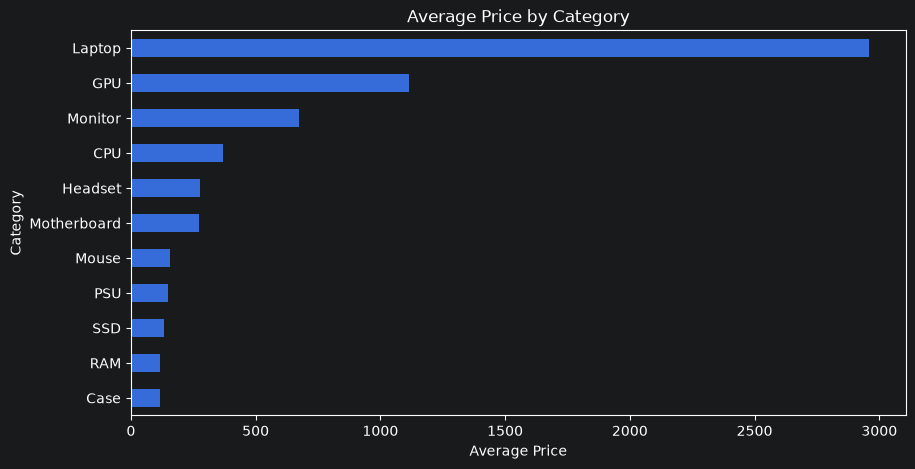

In [15]:
plt.figure(figsize=(10,5))
category_price.sort_values().plot(kind="barh")
plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.show()

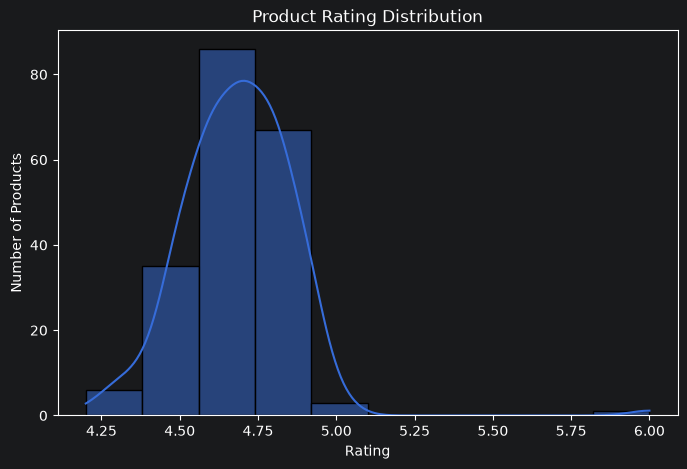

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="rating", bins=10, kde=True)
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

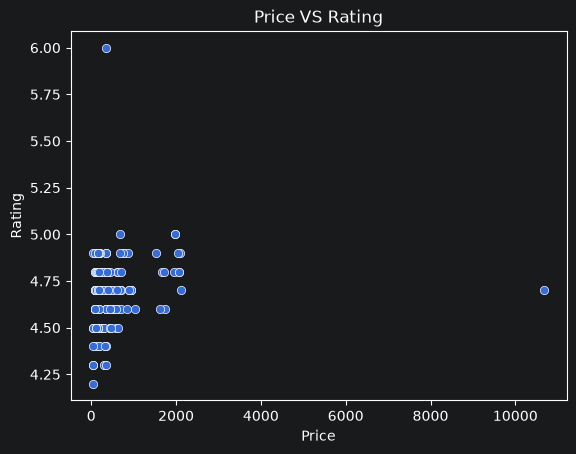

In [17]:
plt.plot(figsize=(8,5))
sns.scatterplot(data=df, x="price", y="rating")
plt.title("Price VS Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

In [18]:
from src.data.preprocessing import clean_products

In [19]:
df_clean = clean_products(df)

In [20]:
df.shape

(200, 7)

In [21]:
df_clean.shape

(188, 7)

In [22]:
df_clean.to_csv("../data/processed/cleaned.csv", index=False)

In [23]:
from src.data.preprocessing import split_data
train_df, val_df, test_df = split_data(df_clean)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)
print("Original:", df.shape)
print("Cleaned:", df_clean.shape)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (150, 7)
Val: (19, 7)
Test: (19, 7)
Original: (200, 7)
Cleaned: (188, 7)
Train: (150, 7)
Val: (19, 7)
Test: (19, 7)
